# Convolutional Neural Networks in Pytorch

<div>
    <img src='../../images/CONV2D.png' width="600">
</div>

In [22]:
import torch

m = torch.nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3
)

f = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=torch.float32)

with torch.no_grad():
    m.weight[0, 0] = f
    m.bias.zero_()

x = torch.tensor([
    [45, 12, 5, 17],
    [22, 10, 35, 6],
    [88, 26, 51, 19],
    [9, 77, 42, 3]
], dtype=torch.float32)

# Pytorch requires (batch, channels, h, w)
input = x.unsqueeze(0).unsqueeze(0)

print("Weight shape:", m.weight.shape)
print("Input shape:", input.shape)

output_py = m(input)

print("Output:")
print(output_py)

Weight shape: torch.Size([1, 1, 3, 3])
Input shape: torch.Size([1, 1, 4, 4])
Output:
tensor([[[[-45., 103.],
          [-96., 133.]]]], grad_fn=<ConvolutionBackward0>)


<div>
    <img src='../../images/POOLLAYER.png' width="600">
</div>

In [33]:
# MAX POOL
x = torch.tensor([
    [45, 12, 5, 17],
    [22, 10, 35, 6],
    [88, 26, 51, 19],
    [9, 77, 42, 3]
], dtype=torch.float32)
input = x.unsqueeze(0).unsqueeze(0)
max_pool = torch.nn.MaxPool2d(2, stride=2)
avg_pool = torch.nn.AvgPool2d(2, stride=2)
output_max = max_pool(input)
output_avg = avg_pool(input)
print(output_max)
print(output_avg)

tensor([[[[45., 35.],
          [88., 51.]]]])
tensor([[[[22.2500, 15.7500],
          [50.0000, 28.7500]]]])


<div>
    <img src='../../images/MULTIFILTERSVALUES.png' width="1000">
</div>

In [34]:
import torch

# Shape (channels, height, width)
X = torch.Tensor([
    [
        [45, 12, 5, 17],
        [22, 10, 35, 6],
        [88, 26, 51, 19],
        [9, 77, 42, 3]
    ],
    [
        [15, 13, 6, 7],
        [23, 14, 3, 6],
        [12, 16, 1, 34],
        [91, 66, 22, 31]
    ],
    [
        [6, 12, 5, 17],
        [52, 14, 38, 8],
        [88, 66, 5, 9],
        [70, 71, 72, 73]
    ]
])

# Shape (filters, channels, k, k)
Fs = torch.Tensor([
    [
        [
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ],
        [
            [0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0]
        ],
        [
            [0, -1, 0],
            [-1, 3, -1],
            [0, -1, 0]
        ]
    ],
    [
        [
            [0, -1, 0],
            [-1, 2, -1],
            [0, -1, 0]
        ],
        [
            [0, -1, 0],
            [-1, 1, -1],
            [0, -1, 0]
        ],
        [
            [0, -1, 0],
            [-1, 0, -1],
            [0, -1, 0]
        ]
    ]
])

m = torch.nn.Conv2d(in_channels=3,
                    out_channels=2,
                    kernel_size=3,
                    stride=1,
                    bias=False)

print(Fs.shape)

with torch.no_grad():
    m.weight[:] = Fs

# (batch, channels, h, w)
input = X.unsqueeze(0)

print("Weight shape:", m.weight.shape)
print("Input shape:", input.shape)

output_py = m(input)

print("Output:")
print(output_py)

torch.Size([2, 3, 3, 3])
Weight shape: torch.Size([2, 3, 3, 3])
Input shape: torch.Size([1, 3, 4, 4])
Output:
tensor([[[[-170.,  170.],
          [-105., -108.]],

         [[-284.,  -58.],
          [-429., -279.]]]], grad_fn=<ConvolutionBackward0>)


In [36]:
max_pool = torch.nn.MaxPool2d(2, stride=1)
print(max_pool(output_py))

tensor([[[[170.]],

         [[-58.]]]], grad_fn=<MaxPool2DWithIndicesBackward0>)


# Pipeline example

Until now was a small matrix just to see the operations, however, in real world an image is nedded.

In [1]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
import math

# Helpers
def conv_output_size(h, w, k_h, k_w, stride=1):
    o_h = math.floor((h - k_h) / stride) + 1
    o_w = math.floor((w - k_w) / stride) + 1
    return o_h, o_w

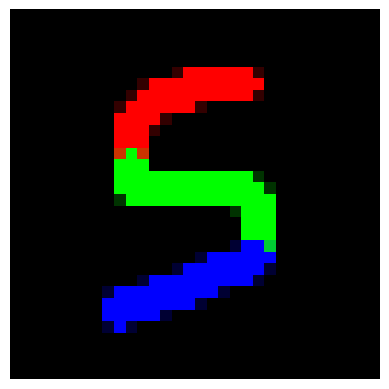

torch.Size([3, 32, 32])


In [2]:
# Cargar imagen
img = Image.open("../images/5.png").convert("RGB")

x = transforms.ToTensor()(img)

plt.imshow(x.permute(1, 2, 0))
plt.axis('off')
plt.show()

print(x.shape)

In this example, will be only classify the image as it is a number or not, so it is a problem of binary classification.

In [101]:
torch.manual_seed(42)

# Add batch dimension
c, h, w = x.shape

# ----- Layers -----
conv = torch.nn.Conv2d(in_channels=c,
                       out_channels=2, # No. filters
                       kernel_size=3,
                       stride=1)
relu = torch.nn.ReLU()
pool = torch.nn.MaxPool2d(
    kernel_size=2,
    stride=2
)

# ----- Compute output size manually -----

conv_h, conv_w = conv_output_size(
    h, w,
    k_h=3,
    k_w=3,
    stride=1
)

pool_h, pool_w = conv_output_size(
    conv_h, conv_w,
    k_h=2,
    k_w=2,
    stride=2
)

# channels * height * width
f = 2 * pool_h * pool_w

linear = torch.nn.Linear(
    in_features=f,
    out_features=1
)

In [102]:
def forward(x):
    input = x.unsqueeze(0) # (1, C, H, W)
    z = conv(input)
    z = relu(z)
    z = pool(z)
    z = z.flatten(start_dim=1) # Se aplana pero mantiene la dimension de batch
    y = linear(z) # logits
    return y

Up to know the convolutional end, but as a continuation, we will add the loss function, assuming we are in a bianry problem. MNIST example will be in the next section

In [ ]:
def calculate_loss(y):
    target = torch.tensor([[1.0]]) # clase positiva (es numero)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    loss = loss_fn(y, target)
    return loss

Now we've come to the backpropagation

In [104]:
# Optimizer
optimizer = torch.optim.SGD(
    params=list(conv.parameters()) + list(linear.parameters()),
    lr=0.01
)

In [105]:
def backward_step(loss):
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
for e in range(50):
    y = forward(x)
    loss = calculate_loss(y) 
    print("Loss:", loss.item())
    backward_step(loss)

Loss: 0.19514822959899902
Loss: 0.1816166639328003
Loss: 0.1692093014717102
Loss: 0.1578424870967865
Loss: 0.14740970730781555
Loss: 0.1378646194934845
Loss: 0.1291307955980301
Loss: 0.12113621085882187
Loss: 0.11381366103887558
Loss: 0.10710107535123825
Loss: 0.10094143450260162
Loss: 0.09528278559446335
Loss: 0.09007933735847473
Loss: 0.08530015498399734
Loss: 0.08089090138673782
Loss: 0.07681717723608017
Loss: 0.07304800301790237
Loss: 0.06954243034124374
Loss: 0.06627207249403
Loss: 0.06323502212762833


In [109]:
# 🔥 Convert logits → probability
prob = torch.sigmoid(y)

print(prob.item())

0.9387227892875671
